In [1]:
import numpy as np
import matplotlib.pyplot as plt

kH = 5e3
Ceq = 2e-3

C0 = 0

In [2]:
def dCdt(C, pH):

    rate = kH * 10**(-pH)

    return rate * (1 - C/Ceq)

In [3]:
def euler_step(C, dt, pH):

    return C + dt*dCdt(C,pH)

In [4]:
def rk4_step(C, dt, pH):

    k1 = dCdt(C,pH)

    k2 = dCdt(C + 0.5*dt*k1, pH)

    k3 = dCdt(C + 0.5*dt*k2, pH)

    k4 = dCdt(C + dt*k3, pH)

    return C + dt*(k1 + 2*k2 + 2*k3 + k4)/6

In [11]:
dt = 0.01
tmax = 5

steps = int(tmax/dt)

time = np.linspace(0,tmax,steps)

pH_values = [5,6,8]

In [12]:
results_euler = {}

for pH in pH_values:

    C = C0
    C_values = []

    for i in range(steps):

        C = euler_step(C,dt,pH)

        C_values.append(C)

    results_euler[pH] = np.array(C_values)

In [13]:
results_rk4 = {}

for pH in pH_values:

    C = C0
    C_values = []

    for i in range(steps):

        C = rk4_step(C,dt,pH)

        C_values.append(C)

    results_rk4[pH] = np.array(C_values)

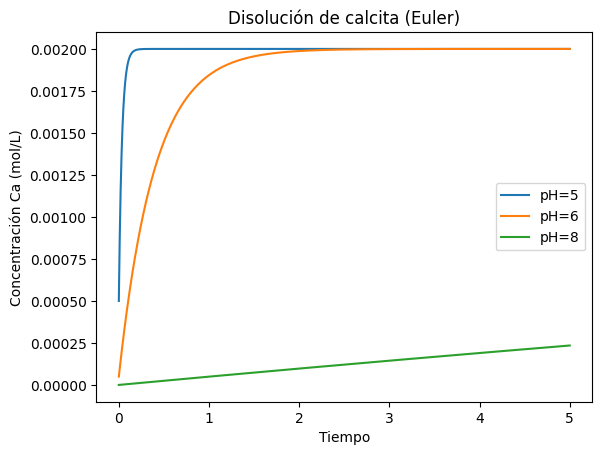

In [14]:
plt.figure()

for pH in pH_values:

    plt.plot(time, results_euler[pH], label=f"pH={pH}")

plt.xlabel("Tiempo")
plt.ylabel("Concentración Ca (mol/L)")
plt.title("Disolución de calcita (Euler)")

plt.legend()
plt.show()

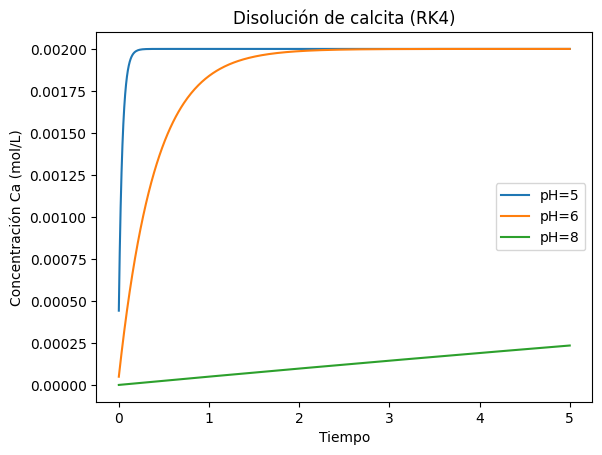

In [15]:
plt.figure()

for pH in pH_values:

    plt.plot(time, results_rk4[pH], label=f"pH={pH}")

plt.xlabel("Tiempo")
plt.ylabel("Concentración Ca (mol/L)")
plt.title("Disolución de calcita (RK4)")

plt.legend()
plt.show()

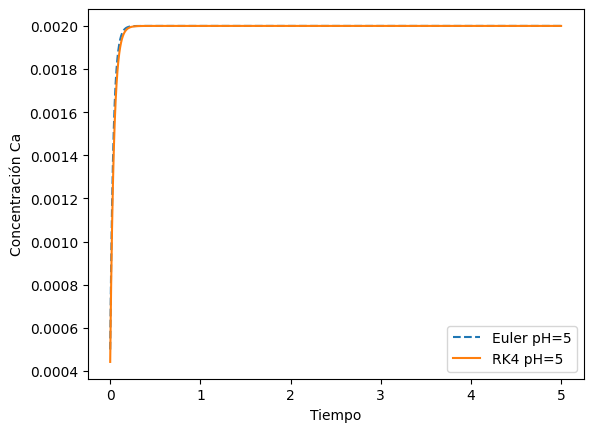

In [16]:
plt.figure()

plt.plot(time, results_euler[5], '--', label="Euler pH=5")
plt.plot(time, results_rk4[5], label="RK4 pH=5")

plt.xlabel("Tiempo")
plt.ylabel("Concentración Ca")

plt.legend()
plt.show()

PREGUNTA A: A menor pH, el término 10^(-pH) es mayor, por lo que la velocidad de disolución aumenta. En el código se simulan pH = 5, 6 y 8, donde pH=5 produce la disolución más rápida y pH=8 la más lenta.

PREGUNTA B: pH bajo significa mayor concentración de H⁺ en la solución. El ion H⁺ ataca la superficie de la calcita (CaCO₃), promoviendo su disolución. Como rate ∝ [H⁺] = 10^(-pH), al bajar una unidad de pH, la velocidad se multiplica por 10

PREGUNTA C: El término (1 - C/Ceq) en dCdt tiende a cero. Esto significa que la disolución se frena progresivamente hasta detenerse cuando C = Ceq = 2e-3 mol/L, que es el equilibrio de saturación. La solución ya no puede disolver más calcita.

Análisis del efecto del paso temporal dt

Al aumentar el paso temporal dt, el método de Euler se vuelve impreciso e inestable porque es un método simple que solo evalúa la derivada una vez por paso. RK4 tolera pasos más grandes sin perder precisión porque promedia cuatro evaluaciones por paso. Con dt = 0.01 ambos funcionan bien, pero si dt fuera mayor, Euler comenzaría a dar resultados incorrectos mientras RK4 se mantendría estable.